In [1]:
import copy
import random
import time
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output

from model import RLmodel
from game import GameEnv, initial_playersize

torch.set_num_threads(2)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

GRID_SIZE = 15
LR = 1e-5
GAMMA = 0.9
TAU = 0.005
BATCH_SIZE = 64
MEMORY_SIZE = 50000
WARMUP = 2000

EPOCHS = 600000
EPISODES_PER_EPOCH = 5
UPDATES_PER_EPOCH = 64
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_FRAC = 0.6

board = GameEnv(GRID_SIZE)
model = RLmodel(GRID_SIZE).to(device)
optimizer = optim.AdamW(model.parameters(), lr = LR)

print('device', device, '| state', board.state_shape())


device mps | state (2, 17, 17)


In [2]:
class replayMemory(object):
    def __init__(self,size = 50000):
        self.buffer = deque(maxlen = size)
    def push(self,s,a,r,s2,done):
        self.buffer.append((s,a,r,s2,done))
    def sample(self,batch):
        s,a,r,s2,done = zip(*random.sample(self.buffer,batch))
        return (torch.from_numpy(np.stack(s)),
                torch.tensor(a,dtype = torch.int64),
                torch.tensor(r,dtype = torch.float32),
                torch.from_numpy(np.stack(s2)),
                torch.tensor(done,dtype = torch.float32))
    def __len__(self):
        return len(self.buffer)
memory = replayMemory()

In [3]:
def pick_action(state, temp):
    with torch.no_grad():
        q = model(torch.from_numpy(state).unsqueeze(0).to(device))[0]
    if temp <= 0:
        return int(q.argmax())
    probs = torch.softmax(q / temp, dim = 0)
    return int(torch.multinomial(probs, 1))


def play(num_episodes, eps):
    total_reward = 0.
    scores = []
    steps = 0
    for _ in range(num_episodes):
        state = board.resetgame()
        while True:
            action = pick_action(state, eps)
            reward, game_over, info = board.update(action)
            next_state = board.get_state()

            memory.push(state, action, reward, next_state, game_over)
            total_reward += reward
            state = next_state
            steps += 1
            if game_over:
                scores.append(info['length'] - initial_playersize)
                break
    return total_reward, np.mean(scores), np.max(scores), steps

    


In [4]:
target_model = copy.deepcopy(model)
for p in target_model.parameters():
    p.requires_grad_(False)

huber = nn.SmoothL1Loss()

def learn(num_updates, batch_size):
    if len(memory) < max(batch_size, WARMUP):
        return 0.
    total_loss = 0.
    for i in range(num_updates):
        states, actions, rewards, next_states, dones = memory.sample(batch_size)
        states      = states.to(device)
        actions     = actions.to(device)
        rewards     = rewards.to(device)
        next_states = next_states.to(device)
        dones       = dones.to(device)

        q = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            best   = model(next_states).argmax(1)
            next_q = target_model(next_states).gather(1, best.unsqueeze(1)).squeeze(1)
            target = rewards + GAMMA * next_q * (1 - dones)

        loss = huber(q, target)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 10)
        optimizer.step()

        with torch.no_grad():
            for tp, p in zip(target_model.parameters(), model.parameters()):
                tp.mul_(1 - TAU).add_(p, alpha = TAU)

        total_loss += loss.item()
    return total_loss / num_updates


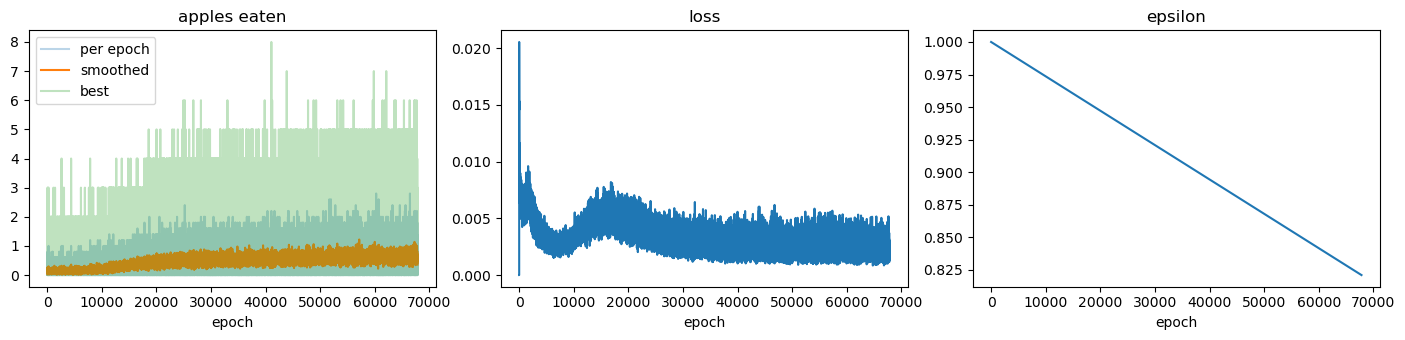

epoch 67810/600000  eps 0.82  mem  50000  steps 18044573  score 0.20  best 1  loss 0.00143  44661s


KeyboardInterrupt: 

In [5]:
hist = {'score':[], 'best':[], 'loss':[], 'eps':[]}
total_steps = 0
start = time.time()

for epoch in range(EPOCHS):
    eps = max(EPS_END, EPS_START - (EPS_START-EPS_END)*epoch/(EPOCHS*EPS_DECAY_FRAC))
    reward, avg_score, best_score, steps = play(EPISODES_PER_EPOCH, eps)
    loss = learn(UPDATES_PER_EPOCH, BATCH_SIZE)
    total_steps += steps

    hist['score'].append(avg_score)
    hist['best'].append(best_score)
    hist['loss'].append(loss)
    hist['eps'].append(eps)

    if epoch % 10 == 0 or epoch == EPOCHS-1:
        clear_output(wait = True)
        smooth = np.convolve(hist['score'], np.ones(10)/10, mode = 'valid') if len(hist['score']) >= 10 else []
        fig, ax = plt.subplots(1, 3, figsize = (14,3.5))
        ax[0].plot(hist['score'], alpha = 0.3, label = 'per epoch')
        if len(smooth): ax[0].plot(range(9,9+len(smooth)), smooth, label = 'smoothed')
        ax[0].plot(hist['best'], alpha = 0.3, label = 'best')
        ax[0].set_title('apples eaten'); ax[0].legend()
        ax[1].plot(hist['loss']); ax[1].set_title('loss')
        ax[2].plot(hist['eps']); ax[2].set_title('epsilon')
        for a in ax: a.set_xlabel('epoch')
        plt.tight_layout(); plt.show()
        print(f"epoch {epoch:4d}/{EPOCHS}  eps {eps:.2f}  mem {len(memory):6d}  "
              f"steps {total_steps:7d}  score {avg_score:.2f}  best {best_score:.0f}  "
              f"loss {loss:.5f}  {time.time()-start:.0f}s")
